<a href="https://colab.research.google.com/github/SarvethElionisAE5087/INTERNMM/blob/main/Sales_Data_EDA_Mugesh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files  # Google Colab file uploader

# Set modern visual layout settings for charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 140


In [ ]:
print("Please select and upload your 'product_sales_dataset.csv' file:")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("\n=== Initial Data Overview ===")
print(df.head(3))
print("\n=== Initial Column Types & Missing Values ===")
df.info()


Please select and upload your 'product_sales_dataset.csv' file:


Saving product_sales_dataset.csv to product_sales_dataset (1).csv

=== Initial Data Overview ===
   Product_ID Product_Name Category  Price_USD  Quantity_Sold  \
0        1001     Lipstick   Beauty         26              7   
1        1002       Jacket  Fashion        254              6   
2        1003   Gym Gloves   Sports         30             10   

   Total_Sales_USD  Order_Date Customer_City  
0              182  2025-01-24       Karachi  
1             1524  2026-04-01      Peshawar  
2              300  2025-11-05      Peshawar  

=== Initial Column Types & Missing Values ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Product_ID       1000 non-null   int64 
 1   Product_Name     1000 non-null   object
 2   Category         1000 non-null   object
 3   Price_USD        1000 non-null   int64 
 4   Quantity_Sold    1000 non-n

In [ ]:
print("\n=== Processing Data Cleaning Tasks ===")

print("Missing values detected per column:")
print(df.isnull().sum())

initial_rows = len(df)
df.drop_duplicates(inplace=True)
dropped_duplicates = initial_rows - len(df)
print(f"-> Deduplication: Removed {dropped_duplicates} duplicate records.")



=== Processing Data Cleaning Tasks ===
Missing values detected per column:
Product_ID         0
Product_Name       0
Category           0
Price_USD          0
Quantity_Sold      0
Total_Sales_USD    0
Order_Date         0
Customer_City      0
dtype: int64
-> Deduplication: Removed 0 duplicate records.


In [ ]:
if 'Total_Sales_USD' in df.columns and 'Price_USD' in df.columns and 'Quantity_Sold' in df.columns:
    df['Total_Sales_USD'] = df['Total_Sales_USD'].fillna(df['Price_USD'] * df['Quantity_Sold'])

df['Customer_City'] = df['Customer_City'].fillna('Unknown')
df['Category'] = df['Category'].fillna('Unknown')

df['Order_Date'] = pd.to_datetime(df['Order_Date'])
print("-> Date formats parsed and corrected successfully.")

print("\n=== Final Integrity Check (Missing values remaining) ===")
print(df.isnull().sum())

-> Date formats parsed and corrected successfully.

=== Final Integrity Check (Missing values remaining) ===
Product_ID         0
Product_Name       0
Category           0
Price_USD          0
Quantity_Sold      0
Total_Sales_USD    0
Order_Date         0
Customer_City      0
dtype: int64


In [ ]:
print("\n=== Statistical Summary of Numerical Columns ===")
desc = df.describe().round(2)
print(desc)

# --- Dynamic statistical observations ---
avg_price    = desc.loc['mean', 'Price_USD'] if 'Price_USD' in desc.columns else None
avg_qty      = desc.loc['mean', 'Quantity_Sold'] if 'Quantity_Sold' in desc.columns else None
avg_sales    = desc.loc['mean', 'Total_Sales_USD'] if 'Total_Sales_USD' in desc.columns else None
max_sales    = desc.loc['max',  'Total_Sales_USD'] if 'Total_Sales_USD' in desc.columns else None
min_sales    = desc.loc['min',  'Total_Sales_USD'] if 'Total_Sales_USD' in desc.columns else None
median_sales = desc.loc['50%',  'Total_Sales_USD'] if 'Total_Sales_USD' in desc.columns else None
std_price    = desc.loc['std',  'Price_USD'] if 'Price_USD' in desc.columns else None

skew_note = (
    "revenue is skewed — a few very high-value transactions are pulling the average up"
    if avg_sales and median_sales and avg_sales > median_sales * 1.2
    else "revenue is fairly evenly distributed across transactions"
)

print(f"""
KEY OBSERVATIONS FROM STATISTICAL SUMMARY:
- The dataset contains {len(df):,} clean records after removing {dropped_duplicates} duplicates.
- Average product price is ${avg_price:,.2f} with a standard deviation of ${std_price:,.2f},
  meaning prices vary widely — the catalogue spans multiple price tiers.
- On average, {avg_qty:.1f} units are sold per transaction.
- Average revenue per transaction is ${avg_sales:,.2f}, ranging from
  ${min_sales:,.2f} (min) to ${max_sales:,.2f} (max).
- Since the mean (${avg_sales:,.2f}) {'is notably higher' if avg_sales > median_sales * 1.2 else 'is close to'}
  the median (${median_sales:,.2f}), {skew_note}.
""")


=== Statistical Summary of Numerical Columns ===
       Product_ID  Price_USD  Quantity_Sold  Total_Sales_USD  \
count     1000.00    1000.00        1000.00          1000.00   
mean      1500.50     253.76           5.46          1371.03   
min       1001.00      10.00           1.00            10.00   
25%       1250.75     126.75           3.00           425.75   
50%       1500.50     255.00           5.00          1040.00   
75%       1750.25     383.25           8.00          2006.25   
max       2000.00     500.00          10.00          5000.00   
std        288.82     144.90           2.96          1156.02   

                          Order_Date  
count                           1000  
mean   2025-09-09 21:15:50.399999744  
min              2025-01-02 00:00:00  
25%              2025-05-11 00:00:00  
50%              2025-09-14 00:00:00  
75%              2026-01-09 06:00:00  
max              2026-05-16 00:00:00  
std                              NaN  

KEY OBSERVATIONS FROM

In [ ]:
print("\n=== Compiling Exploratory Data Analysis Metrics ===")

top_products     = df.groupby('Product_Name')['Total_Sales_USD'].sum().sort_values(ascending=False).head(5)
category_revenue = df.groupby('Category')['Total_Sales_USD'].sum().sort_values(ascending=False)
city_sales       = df.groupby('Customer_City')['Total_Sales_USD'].sum().sort_values(ascending=False)
price_qty_corr   = df['Price_USD'].corr(df['Quantity_Sold'])

df['Month']    = df['Order_Date'].dt.to_period('M')
monthly_sales  = df.groupby('Month')['Total_Sales_USD'].sum()

print("\n[Top 5 Best-Selling Products]");  print(top_products)
print("\n[Revenue Distribution Across Categories]");  print(category_revenue)
print("\n[City-wise Revenue Standings]");  print(city_sales)
print(f"\nTop Revenue Generator City: {city_sales.index[0]} (${city_sales.values[0]:,.2f})")
print(f"\n[Price vs. Quantity Sold Correlation]: {price_qty_corr:.4f}")



=== Compiling Exploratory Data Analysis Metrics ===

[Top 5 Best-Selling Products]
Product_Name
Tennis Ball    96227
Gym Gloves     80127
Table          74455
Lipstick       72172
Face Wash      70936
Name: Total_Sales_USD, dtype: int64

[Revenue Distribution Across Categories]
Category
Sports         310674
Beauty         249665
Home           233891
Books          202704
Fashion        200854
Electronics    173244
Name: Total_Sales_USD, dtype: int64

[City-wise Revenue Standings]
Customer_City
Peshawar     284654
Islamabad    281637
Lahore       271491
Karachi      269551
Quetta       263699
Name: Total_Sales_USD, dtype: int64

Top Revenue Generator City: Peshawar ($284,654.00)

[Price vs. Quantity Sold Correlation]: -0.0308


In [ ]:
print("\n=== Generating Required Charts ===")


=== Generating Required Charts ===


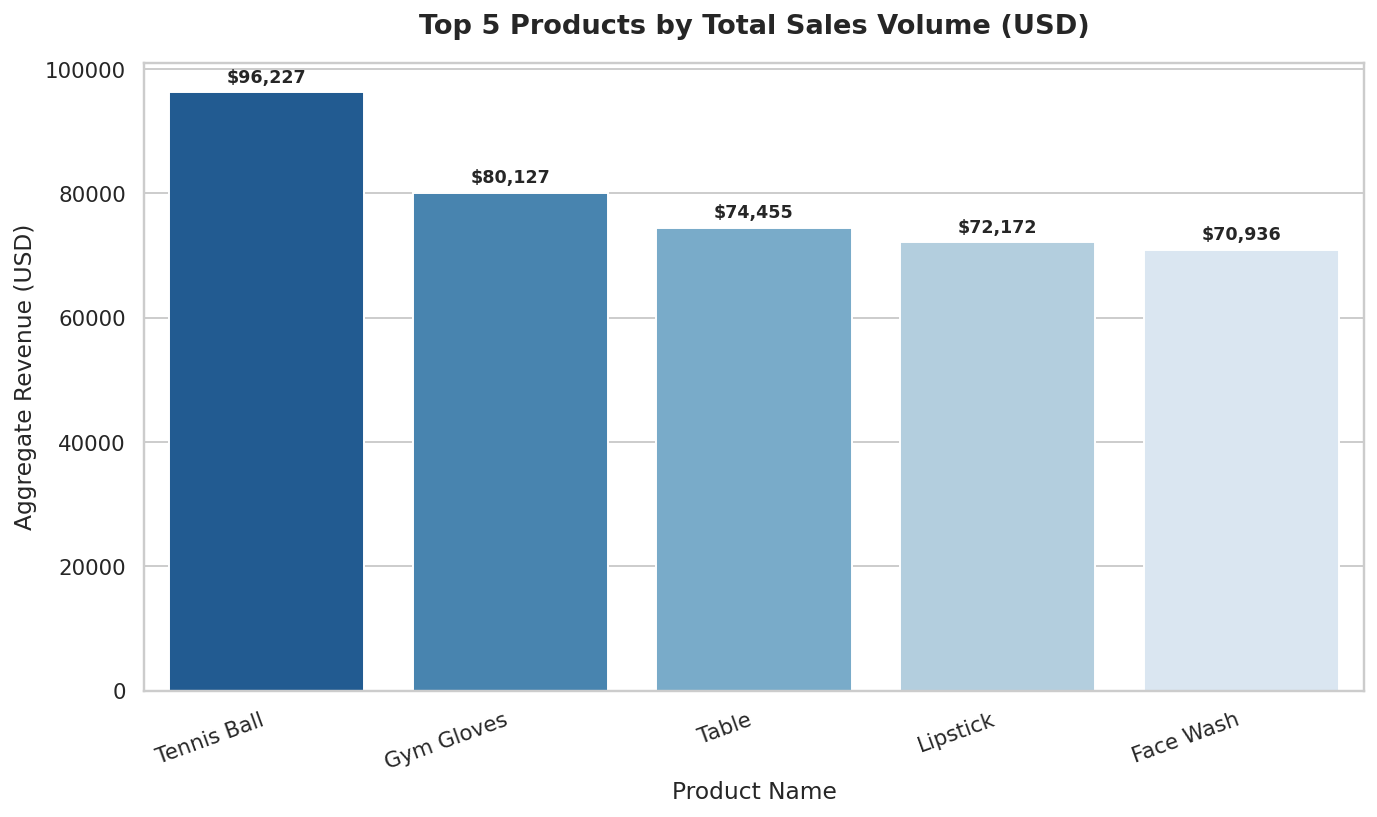


OBSERVATION — Chart 1 (Bar Chart: Top 5 Products):
- 'Tennis Ball' is the top-selling product with $96,227.00 in total revenue,
  outperforming the 5th-ranked product 'Face Wash' ($70,936.00)
  by $25,291.00 — a 35.7% gap.
- Together, the top 5 products contribute $393,917.00, which is
  28.7% of the company's entire revenue — showing moderate
  dependence on a small product group.
- Inventory and marketing resources should be prioritised for 'Tennis Ball'
  to protect and grow this revenue anchor.



In [ ]:
plt.figure()
sns.barplot(x=top_products.index, y=top_products.values,
            hue=top_products.index, palette="Blues_r", legend=False)
plt.title('Top 5 Products by Total Sales Volume (USD)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Aggregate Revenue (USD)', fontsize=12)
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(top_products.values):
    plt.text(i, v + (max(top_products.values) * 0.01), f'${v:,.0f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_top5_products.png', dpi=140, bbox_inches='tight')
plt.show()

# Dynamic values
top1_name     = top_products.index[0]
top1_rev      = top_products.values[0]
top5_last     = top_products.index[-1]
top5_last_rev = top_products.values[-1]
revenue_gap   = top1_rev - top5_last_rev
top5_total    = top_products.sum()
all_total     = df['Total_Sales_USD'].sum()
top5_share    = (top5_total / all_total) * 100

print(f"""
OBSERVATION — Chart 1 (Bar Chart: Top 5 Products):
- '{top1_name}' is the top-selling product with ${top1_rev:,.2f} in total revenue,
  outperforming the 5th-ranked product '{top5_last}' (${top5_last_rev:,.2f})
  by ${revenue_gap:,.2f} — a {((revenue_gap/top5_last_rev)*100):.1f}% gap.
- Together, the top 5 products contribute ${top5_total:,.2f}, which is
  {top5_share:.1f}% of the company's entire revenue — showing {'heavy' if top5_share > 50 else 'moderate'}
  dependence on a small product group.
- Inventory and marketing resources should be prioritised for '{top1_name}'
  to protect and grow this revenue anchor.
""")


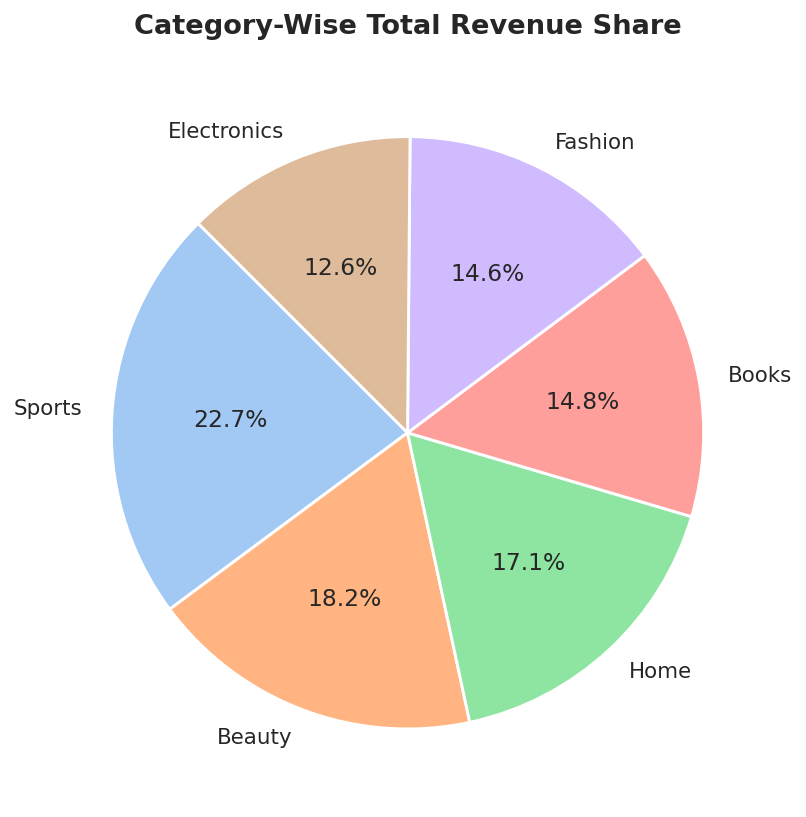

In [ ]:
plt.figure()
plt.pie(category_revenue.values, labels=category_revenue.index,
        autopct='%1.1f%%', startangle=135,
        colors=sns.color_palette('pastel', len(category_revenue)),
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Category-Wise Total Revenue Share', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart2_category_revenue.png', dpi=140, bbox_inches='tight')
plt.show()

# Dynamic values
total_cat_rev  = category_revenue.sum()
top_cat_name   = category_revenue.index[0]
top_cat_rev    = category_revenue.values[0]
top_cat_pct    = (top_cat_rev / total_cat_rev) * 100
top2_cat_pct   = (category_revenue.values[:2].sum() / total_cat_rev) * 100
last_cat_name  = category_revenue.index[-1]
last_cat_pct   = (category_revenue.values[-1] / total_cat_rev) * 100
num_cats       = len(category_revenue)
is_dominant    = top_cat_pct >= 40

In [ ]:
total_cat_rev  = category_revenue.sum()
top_cat_name   = category_revenue.index[0]
top_cat_rev    = category_revenue.values[0]
top_cat_pct    = (top_cat_rev / total_cat_rev) * 100
top2_cat_pct   = (category_revenue.values[:2].sum() / total_cat_rev) * 100
last_cat_name  = category_revenue.index[-1]
last_cat_pct   = (category_revenue.values[-1] / total_cat_rev) * 100
num_cats       = len(category_revenue)
is_dominant    = top_cat_pct >= 40

if is_dominant:
    cat_line1 = (f"- '{top_cat_name}' dominates with {top_cat_pct:.1f}% of total revenue "
                 f"(${top_cat_rev:,.2f}). The top 2 categories together hold {top2_cat_pct:.1f}%.")
    cat_line2 = (f"- With {num_cats} categories in total, the business is heavily concentrated. "
                 f"If '{top_cat_name}' demand drops, overall revenue will be significantly impacted.")
    cat_line3 = (f"- '{last_cat_name}' contributes only {last_cat_pct:.1f}% — this segment "
                 f"either needs investment to grow or review to assess if it remains viable.")
else:
    cat_line1 = (f"- Revenue is well spread across all {num_cats} categories. "
                 f"'{top_cat_name}' leads with {top_cat_pct:.1f}% (${top_cat_rev:,.2f}), "
                 f"but no single category dominates.")
    cat_line2 = ("- This healthy diversification means the business is not over-dependent "
                 "on any one segment, reducing revenue risk.")
    cat_line3 = (f"- '{last_cat_name}' contributes {last_cat_pct:.1f}%. Selectively boosting "
                 f"the top 1-2 categories could create a stronger revenue anchor.")

print(f"""
OBSERVATION — Chart 2 (Pie Chart: Category Revenue Share):
{cat_line1}
{cat_line2}
{cat_line3}
""")


OBSERVATION — Chart 2 (Pie Chart: Category Revenue Share):
- Revenue is well spread across all 6 categories. 'Sports' leads with 22.7% ($310,674.00), but no single category dominates.
- This healthy diversification means the business is not over-dependent on any one segment, reducing revenue risk.
- 'Electronics' contributes 12.6%. Selectively boosting the top 1-2 categories could create a stronger revenue anchor.



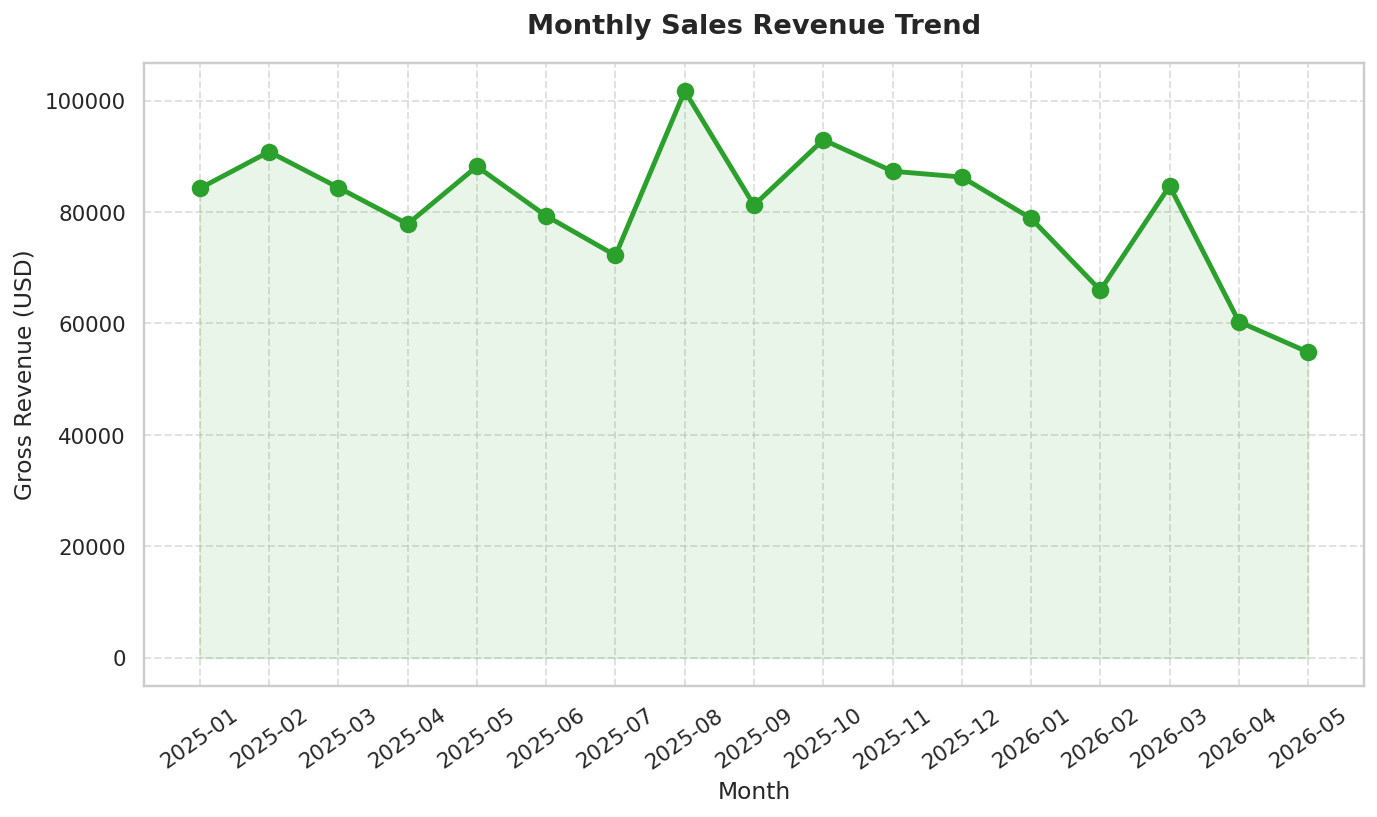


OBSERVATION — Chart 3 (Line Chart: Monthly Sales Trend):
- Peak revenue month is 2025-08 with $101,723.00 — that is 26.1%
  above the monthly average of $80,648.94, indicating a strong seasonal spike.
- The lowest revenue month is 2026-05 ($54,841.00), which is 32.0%
  below the monthly average — a key slow period that needs promotional support.
- Comparing the first month to the last, the overall trend is downward
  (34.9% change), which needs attention and corrective strategy.



In [ ]:
plt.figure()
months_format = [str(m) for m in monthly_sales.index]
plt.plot(months_format, monthly_sales.values,
         marker='o', color='#2ca02c', linewidth=2.5, markersize=8)
plt.fill_between(months_format, monthly_sales.values, alpha=0.1, color='#2ca02c')
plt.title('Monthly Sales Revenue Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Gross Revenue (USD)', fontsize=12)
plt.xticks(rotation=35)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('chart3_monthly_trend.png', dpi=140, bbox_inches='tight')
plt.show()

# Dynamic values
peak_month     = str(monthly_sales.idxmax())
peak_rev       = monthly_sales.max()
low_month      = str(monthly_sales.idxmin())
low_rev        = monthly_sales.min()
avg_monthly    = monthly_sales.mean()
peak_vs_avg    = ((peak_rev - avg_monthly) / avg_monthly) * 100
low_vs_avg     = ((avg_monthly - low_rev) / avg_monthly) * 100
first_rev      = monthly_sales.iloc[0]
last_rev       = monthly_sales.iloc[-1]
trend_dir      = "upward" if last_rev > first_rev else "downward"
trend_pct      = abs((last_rev - first_rev) / first_rev) * 100

print(f"""
OBSERVATION — Chart 3 (Line Chart: Monthly Sales Trend):
- Peak revenue month is {peak_month} with ${peak_rev:,.2f} — that is {peak_vs_avg:.1f}%
  above the monthly average of ${avg_monthly:,.2f}, indicating a strong seasonal spike.
- The lowest revenue month is {low_month} (${low_rev:,.2f}), which is {low_vs_avg:.1f}%
  below the monthly average — a key slow period that needs promotional support.
- Comparing the first month to the last, the overall trend is {trend_dir}
  ({trend_pct:.1f}% change), {'suggesting business growth over this period.' if trend_dir == 'upward' else 'which needs attention and corrective strategy.'}
""")

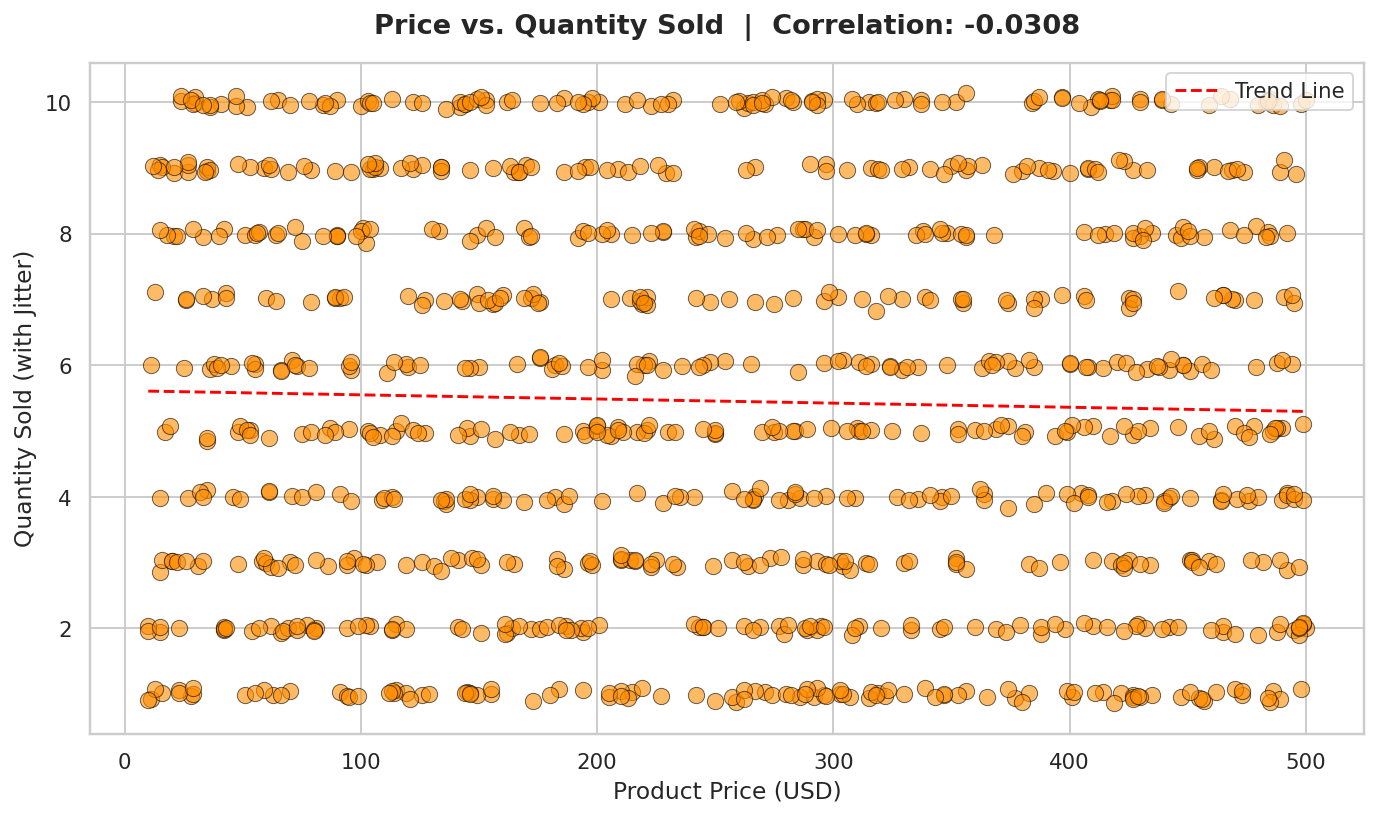


OBSERVATION — Chart 4 (Scatter Plot: Price vs. Quantity Sold):
- The correlation coefficient is -0.0308 — a near-zero relationship,
  meaning price has almost no influence on how many units are sold — customers buy based on need or loyalty, not price.
- The business has strong pricing power and can test modest price increases.
- The red trend line visually confirms this downward direction across all price points.



In [ ]:
plt.figure()
jittered_qty = df['Quantity_Sold'] + np.random.normal(0, 0.05, size=len(df))
sns.scatterplot(x=df['Price_USD'], y=jittered_qty,
                color='darkorange', alpha=0.6, s=70,
                edgecolor='black', linewidth=0.5)
z = np.polyfit(df['Price_USD'], df['Quantity_Sold'], 1)
p_fn = np.poly1d(z)
x_sorted = np.sort(df['Price_USD'].values)
plt.plot(x_sorted, p_fn(x_sorted), color='red', linewidth=1.5,
         linestyle='--', label='Trend Line')
plt.legend()
plt.title(f'Price vs. Quantity Sold  |  Correlation: {price_qty_corr:.4f}',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Price (USD)', fontsize=12)
plt.ylabel('Quantity Sold (with Jitter)', fontsize=12)
plt.tight_layout()
plt.savefig('chart4_price_vs_quantity.png', dpi=140, bbox_inches='tight')
plt.show()

# Dynamic interpretation of correlation
if price_qty_corr < -0.5:
    corr_strength = "strong negative"
    corr_meaning  = (f"higher-priced products clearly sell fewer units — classic price "
                     f"elasticity. Customers are price-sensitive in this market.")
    corr_action   = "Consider competitive pricing or bundle offers to maintain volume on premium products."
elif price_qty_corr < -0.2:
    corr_strength = "weak negative"
    corr_meaning  = ("there is a slight tendency for higher-priced products to sell "
                     "fewer units, but price is not the only deciding factor.")
    corr_action   = "Other factors like brand, quality, or category likely influence purchase decisions too."
elif price_qty_corr < 0.2:
    corr_strength = "near-zero"
    corr_meaning  = ("price has almost no influence on how many units are sold — "
                     "customers buy based on need or loyalty, not price.")
    corr_action   = "The business has strong pricing power and can test modest price increases."
else:
    corr_strength = "positive"
    corr_meaning  = ("higher-priced products actually sell more units — likely because "
                     "premium products signal quality in this market.")
    corr_action   = "Investing in premium product lines could grow both revenue and volume simultaneously."

print(f"""
OBSERVATION — Chart 4 (Scatter Plot: Price vs. Quantity Sold):
- The correlation coefficient is {price_qty_corr:.4f} — a {corr_strength} relationship,
  meaning {corr_meaning}
- {corr_action}
- The red trend line visually confirms this {trend_dir} direction across all price points.
""")

In [ ]:
top_city_name    = city_sales.index[0]
top_city_rev     = city_sales.values[0]
top_city_pct     = (top_city_rev / city_sales.sum()) * 100
second_city      = city_sales.index[1] if len(city_sales) > 1 else "other cities"
second_city_rev  = city_sales.values[1] if len(city_sales) > 1 else 0
city_gap         = top_city_rev - second_city_rev

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║           FINAL BUSINESS RECOMMENDATIONS                        ║
╚══════════════════════════════════════════════════════════════════╝

Based on the data analysis above, here are 3 actionable recommendations:

────────────────────────────────────────────────────────────────────
RECOMMENDATION 1: Protect & Scale the Top-Performing Products
────────────────────────────────────────────────────────────────────
'{top1_name}' alone generates ${top1_rev:,.2f} in revenue and leads
the top 5 products which together account for {top5_share:.1f}% of
total business revenue.

  • Maintain priority stock levels for '{top1_name}' to prevent
    stockouts during peak month ({peak_month}).
  • Bundle '{top5_last}' (lowest of the top 5 at ${top5_last_rev:,.2f})
    with the top product to lift its revenue without extra marketing spend.
  • Review products outside the top 5 for discontinuation or
    repositioning to free up resources.

────────────────────────────────────────────────────────────────────
RECOMMENDATION 2: Double Investment in '{top_city_name}'
────────────────────────────────────────────────────────────────────
'{top_city_name}' contributes ${top_city_rev:,.2f} ({top_city_pct:.1f}%
of total revenue) — ${city_gap:,.2f} more than the next city '{second_city}'
(${second_city_rev:,.2f}).

  • Strengthen delivery speed, local partnerships, and city-specific
    promotions in '{top_city_name}' to defend this revenue base.
  • Investigate why '{top_city_name}' outperforms and apply those
    learnings to '{second_city}' as the next growth target.
  • Run geo-targeted ads in the bottom-performing cities to reduce
    revenue concentration risk.

────────────────────────────────────────────────────────────────────
RECOMMENDATION 3: Plan Around the {peak_month} Peak & {low_month} Dip
────────────────────────────────────────────────────────────────────
Data shows {peak_month} is the strongest month (${peak_rev:,.2f},
{peak_vs_avg:.1f}% above average) while {low_month} is the weakest
(${low_rev:,.2f}, {low_vs_avg:.1f}% below average).

  • Begin inventory build-up 4–6 weeks before {peak_month} to
    prevent stockouts during the highest-demand window.
  • Launch targeted discount campaigns in {low_month} to reduce
    the revenue dip and maintain cash flow.
  • Set monthly sales targets using the actual average of
    ${avg_monthly:,.2f} as the baseline KPI, not a flat annual estimate.

════════════════════════════════════════════════════════════════════
  Analysis Complete. All tasks fulfilled per project requirements.
════════════════════════════════════════════════════════════════════
""")


╔══════════════════════════════════════════════════════════════════╗
║           FINAL BUSINESS RECOMMENDATIONS                        ║
╚══════════════════════════════════════════════════════════════════╝

Based on the data analysis above, here are 3 actionable recommendations:

────────────────────────────────────────────────────────────────────
RECOMMENDATION 1: Protect & Scale the Top-Performing Products
────────────────────────────────────────────────────────────────────
'Tennis Ball' alone generates $96,227.00 in revenue and leads
the top 5 products which together account for 28.7% of
total business revenue.

  • Maintain priority stock levels for 'Tennis Ball' to prevent
    stockouts during peak month (2025-08).
  • Bundle 'Face Wash' (lowest of the top 5 at $70,936.00)
    with the top product to lift its revenue without extra marketing spend.
  • Review products outside the top 5 for discontinuation or
    repositioning to free up resources.

────────────────────────────────